In [11]:
from __future__ import annotations

import csv
import itertools
import json
import math
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

DEFAULT_WEIGHTS = {
    "ttp_only":  (1.00, 0.00, 0.00, 0.00),
    "equal":     (0.25, 0.25, 0.25, 0.25),
    "theory":    (0.40, 0.20, 0.20, 0.20),
    "ttp_heavy": (0.55, 0.15, 0.15, 0.15),
}

VALIDATION_SCORES = {
    "ttp_only": "composite_ttp_only",
    "equal": "composite_equal",
    "theory": "composite_theory",
    "ttp_heavy": "composite_ttp_heavy",
    "grid_country_min_each_0.10": "composite_grid_country_min_each_0.10",
    "grid_agency_min_each_0.10": "composite_grid_agency_min_each_0.10",
}

AGENCY_COLORS = {
    "RU-GRU":   "#9f2d20",
    "RU-FSB":   "#225c7a",
    "RU-SVR":   "#6f4c9b",
    "DPRK-RGB": "#6a6a6a",
    "CHN-MSS":  "#b06c1f",
    "":         "#909090",
}

In [12]:
def jaccard(left: set[str], right: set[str]) -> float:
    union = left | right
    return len(left & right) / len(union) if union else 0.0


def cosine_sparse(left: dict[str, float], right: dict[str, float]) -> float:
    keys = set(left) | set(right)
    numerator = sum(left.get(key, 0.0) * right.get(key, 0.0) for key in keys)
    left_norm = math.sqrt(sum(value * value for value in left.values()))
    right_norm = math.sqrt(sum(value * value for value in right.values()))
    return numerator / (left_norm * right_norm) if left_norm and right_norm else 0.0


def overlap(left: set[str], right: set[str]) -> float:
    denominator = min(len(left), len(right))
    return len(left & right) / denominator if denominator else 0.0

In [13]:
def normalize_agency(affiliation: str | None, *, keep_ambiguous: bool) -> str | None:
    text = (affiliation or "").lower()

    if "rgb" in text:
        return "DPRK-RGB"
    if "mss" in text:
        return "CHN-MSS"
    if "svr" in text:
        return "RU-SVR"
    if "fsb" in text and "gru" in text:
        return "RU-FSB/GRU" if keep_ambiguous else None
    if "ties" in text or "linked" in text or "belarus" in text:
        return "MIXED/LINKED" if keep_ambiguous else None
    if "gru" in text or "74455" in text or "26165" in text or "cniihm" in text:
        return "RU-GRU"
    if "fsb" in text:
        return "RU-FSB"
    return None


def tactical_profile(group: dict) -> dict[str, float]:
    counts: Counter[str] = Counter()
    for technique in group.get("techniques", {}).values():
        counts.update(technique.get("tactics", []))

    total = sum(counts.values())
    if not total:
        return {}
    return {tactic: count / total for tactic, count in counts.items()}


def load_features(data_path: Path, *, keep_ambiguous_agencies: bool) -> dict[str, dict]:
    with data_path.open(encoding="utf-8") as handle:
        raw = json.load(handle)

    features: dict[str, dict] = {}
    for group_id, group in raw.items():
        software = {
            item["name"]
            for item in group.get("software", [])
            if item.get("name")
        }
        features[group_id] = {
            "group_id": group_id,
            "name": group["name"],
            "country": group.get("country"),
            "agency": normalize_agency(
                group.get("affiliation"),
                keep_ambiguous=keep_ambiguous_agencies,
            ),
            "affiliation": group.get("affiliation"),
            "intent": group.get("primary_intent"),
            "techniques": set(group.get("techniques", {})),
            "target_sectors": set(group.get("target_sectors", [])),
            "software": software,
            "tactical_profile": tactical_profile(group),
        }
    return features

In [14]:
def pair_components(left: dict, right: dict) -> dict[str, float]:
    return {
        "jaccard_ttp": jaccard(left["techniques"], right["techniques"]),
        "cosine_ttp": cosine_sparse(
            {key: 1.0 for key in left["techniques"]},
            {key: 1.0 for key in right["techniques"]},
        ),
        "overlap_ttp": overlap(left["techniques"], right["techniques"]),
        "sector_jaccard": jaccard(left["target_sectors"], right["target_sectors"]),
        "software_jaccard": jaccard(left["software"], right["software"]),
        "tactical_cosine": cosine_sparse(
            left["tactical_profile"],
            right["tactical_profile"],
        ),
    }


def composite(components: dict[str, float], weights: tuple[float, float, float, float]) -> float:
    ttp_weight, sector_weight, software_weight, tactical_weight = weights
    return (
        ttp_weight * components["jaccard_ttp"]
        + sector_weight * components["sector_jaccard"]
        + software_weight * components["software_jaccard"]
        + tactical_weight * components["tactical_cosine"]
    )


def build_pair_rows(features: dict[str, dict]) -> list[dict]:
    rows: list[dict] = []
    for left_id, right_id in itertools.combinations(features, 2):
        left = features[left_id]
        right = features[right_id]
        components = pair_components(left, right)
        row = {
            "left_id": left_id,
            "left_name": left["name"],
            "left_country": left["country"],
            "left_agency": left["agency"] or "",
            "right_id": right_id,
            "right_name": right["name"],
            "right_country": right["country"],
            "right_agency": right["agency"] or "",
            **components,
        }
        for label, weights in DEFAULT_WEIGHTS.items():
            row[f"composite_{label}"] = composite(components, weights)
        rows.append(row)
    return rows

In [15]:
def split_scores(
    rows: list[dict],
    objective: str,
    weights: tuple[float, float, float, float],
) -> tuple[list[float], list[float]]:
    intra: list[float] = []
    inter: list[float] = []

    for row in rows:
        score = composite(row, weights)
        if objective == "country":
            left_is_ru = row["left_country"] == "Russia"
            right_is_ru = row["right_country"] == "Russia"
            if left_is_ru and right_is_ru:
                intra.append(score)
            elif left_is_ru != right_is_ru:
                inter.append(score)
        elif objective == "agency":
            left_agency = row["left_agency"]
            right_agency = row["right_agency"]
            if not left_agency or not right_agency:
                continue
            if left_agency == right_agency:
                intra.append(score)
            else:
                inter.append(score)
        else:
            raise ValueError(f"Unknown objective: {objective}")

    return intra, inter


def grid_search(
    rows: list[dict],
    objective: str,
    step: float,
    *,
    min_ttp_weight: float = 0.0,
    min_each_weight: float = 0.0,
    max_each_weight: float = 1.0,
) -> dict:
    units = round(1 / step)
    best: dict | None = None

    for w1 in range(units + 1):
        for w2 in range(units + 1 - w1):
            for w3 in range(units + 1 - w1 - w2):
                w4 = units - w1 - w2 - w3
                weights = tuple(value / units for value in (w1, w2, w3, w4))
                if weights[0] < min_ttp_weight:
                    continue
                if min(weights) < min_each_weight:
                    continue
                if max(weights) > max_each_weight:
                    continue
                intra, inter = split_scores(rows, objective, weights)
                if not intra or not inter:
                    continue
                intra_avg = sum(intra) / len(intra)
                inter_avg = sum(inter) / len(inter)
                result = {
                    "objective": objective,
                    "weights": weights,
                    "intra_avg": intra_avg,
                    "inter_avg": inter_avg,
                    "delta": intra_avg - inter_avg,
                    "intra_pairs": len(intra),
                    "inter_pairs": len(inter),
                }
                if best is None or result["delta"] > best["delta"]:
                    best = result

    if best is None:
        raise ValueError(f"Cannot optimize objective: {objective}")
    return best


def summarize_weight_set(rows: list[dict], label: str, weights: tuple[float, float, float, float]) -> dict:
    summary = {"label": label, "weights": weights}
    for objective in ("country", "agency"):
        intra, inter = split_scores(rows, objective, weights)
        summary[f"{objective}_intra_avg"] = sum(intra) / len(intra) if intra else 0.0
        summary[f"{objective}_inter_avg"] = sum(inter) / len(inter) if inter else 0.0
        summary[f"{objective}_delta"] = summary[f"{objective}_intra_avg"] - summary[f"{objective}_inter_avg"]
        summary[f"{objective}_intra_pairs"] = len(intra)
        summary[f"{objective}_inter_pairs"] = len(inter)
    return summary


def add_composite_column(rows: list[dict], column: str, weights: tuple[float, float, float, float]) -> None:
    for row in rows:
        row[column] = composite(row, weights)

In [16]:
def pair_key(left_id: str, right_id: str) -> tuple[str, str]:
    return tuple(sorted((left_id, right_id)))


def load_ground_truth(path: Path) -> dict[tuple[str, str], dict]:
    if not path.exists():
        return {}

    with path.open(encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        return {
            pair_key(row["left_id"], row["right_id"]): row
            for row in reader
            if row.get("expected_link") == "1"
        }


def annotate_ground_truth(rows: list[dict], ground_truth: dict[tuple[str, str], dict]) -> None:
    for row in rows:
        key = pair_key(row["left_id"], row["right_id"])
        truth = ground_truth.get(key)
        row["ground_truth_link"] = 1 if truth else 0
        row["ground_truth_confidence"] = truth.get("confidence", "") if truth else ""
        row["ground_truth_relation_type"] = truth.get("relation_type", "") if truth else ""
        row["ground_truth_note"] = truth.get("note", "") if truth else ""


def validation_by_threshold(rows: list[dict], score_column: str) -> list[dict]:
    thresholds = [round(value / 100, 2) for value in range(0, 101, 5)]
    total_positive = sum(int(row["ground_truth_link"]) for row in rows)
    output = []

    for threshold in thresholds:
        predicted = [row for row in rows if row[score_column] >= threshold]
        tp = sum(1 for row in predicted if row["ground_truth_link"])
        fp = len(predicted) - tp
        fn = total_positive - tp
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        output.append(
            {
                "score": score_column,
                "threshold": threshold,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "predicted_edges": len(predicted),
                "precision": precision,
                "recall": recall,
                "f1": f1,
            }
        )
    return output


def validation_summary(rows: list[dict]) -> list[dict]:
    output = []
    for label, score_column in VALIDATION_SCORES.items():
        threshold_rows = validation_by_threshold(rows, score_column)
        best = max(threshold_rows, key=lambda item: (item["f1"], item["precision"], item["recall"]))
        ranked = sorted(rows, key=lambda row: row[score_column], reverse=True)
        gt_ranks = [
            index
            for index, row in enumerate(ranked, start=1)
            if row["ground_truth_link"]
        ]
        top_10_hits = sum(1 for row in ranked[:10] if row["ground_truth_link"])
        top_15_hits = sum(1 for row in ranked[:15] if row["ground_truth_link"])
        mean_gt_rank = sum(gt_ranks) / len(gt_ranks) if gt_ranks else 0.0
        output.append(
            {
                "label": label,
                "score_column": score_column,
                "best_threshold": best["threshold"],
                "best_precision": best["precision"],
                "best_recall": best["recall"],
                "best_f1": best["f1"],
                "best_tp": best["tp"],
                "best_fp": best["fp"],
                "best_fn": best["fn"],
                "top_10_gt_hits": top_10_hits,
                "top_15_gt_hits": top_15_hits,
                "mean_ground_truth_rank": mean_gt_rank,
            }
        )
    return output


def ground_truth_rank_rows(rows: list[dict]) -> list[dict]:
    ranks: dict[str, dict[tuple[str, str], int]] = {}
    for label, score_column in VALIDATION_SCORES.items():
        ranked = sorted(rows, key=lambda row: row[score_column], reverse=True)
        ranks[label] = {
            pair_key(row["left_id"], row["right_id"]): index
            for index, row in enumerate(ranked, start=1)
        }

    output = []
    for row in rows:
        if not row["ground_truth_link"]:
            continue
        key = pair_key(row["left_id"], row["right_id"])
        output.append(
            {
                "pair": f"{row['left_name']} - {row['right_name']}",
                "confidence": row["ground_truth_confidence"],
                "relation_type": row["ground_truth_relation_type"],
                "ttp_only_score": row["composite_ttp_only"],
                "theory_score": row["composite_theory"],
                "grid_country_score": row["composite_grid_country_min_each_0.10"],
                "grid_agency_score": row["composite_grid_agency_min_each_0.10"],
                "ttp_only_rank": ranks["ttp_only"][key],
                "theory_rank": ranks["theory"][key],
                "grid_country_rank": ranks["grid_country_min_each_0.10"][key],
                "grid_agency_rank": ranks["grid_agency_min_each_0.10"][key],
            }
        )
    return sorted(output, key=lambda item: item["theory_rank"])

In [17]:
def write_csv(path: Path, rows: list[dict], fieldnames: list[str]) -> None:
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="ignore")
        writer.writeheader()
        writer.writerows(rows)


def write_validation_report(path: Path, summary_rows: list[dict], rank_rows: list[dict]) -> None:
    lines = [
        "# Ground Truth Validation Report",
        "",
        "## Best Threshold Results",
        "",
        "| Metric | Threshold | Precision | Recall | F1 | TP | FP | FN | GT hits in top 10 | Mean GT rank |",
        "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for row in summary_rows:
        lines.append(
            f"| {row['label']} | {row['best_threshold']:.2f} | "
            f"{row['best_precision']:.3f} | {row['best_recall']:.3f} | "
            f"{row['best_f1']:.3f} | {row['best_tp']} | {row['best_fp']} | "
            f"{row['best_fn']} | {row['top_10_gt_hits']} | "
            f"{row['mean_ground_truth_rank']:.1f} |"
        )

    lines.extend(
        [
            "",
            "## Ground Truth Pair Ranking",
            "",
            "| Pair | Confidence | Relation | TTP-only rank | Theory rank | Grid-country rank | Grid-agency rank |",
            "|---|---|---|---:|---:|---:|---:|",
        ]
    )
    for row in rank_rows:
        lines.append(
            f"| {row['pair']} | {row['confidence']} | {row['relation_type']} | "
            f"{row['ttp_only_rank']} | {row['theory_rank']} | "
            f"{row['grid_country_rank']} | {row['grid_agency_rank']} |"
        )

    lines.extend(
        [
            "",
            "## Interpretation",
            "",
            "The validation treats all non-ground-truth pairs as negatives for proof-of-concept evaluation. "
            "This is a conservative simplification: some unlisted pairs may have real but undocumented relationships. "
            "The most important evidence is therefore not a single absolute F1 value, but whether known links move upward in the ranking "
            "when strategic dimensions are added to TTP overlap.",
            "",
        ]
    )
    path.write_text("\n".join(lines), encoding="utf-8")


def write_markdown_report(
    path: Path,
    rows: list[dict],
    summaries: list[dict],
    best_country: dict,
    best_agency: dict,
) -> None:
    top_jaccard = sorted(rows, key=lambda row: row["jaccard_ttp"], reverse=True)[:10]
    top_theory = sorted(rows, key=lambda row: row["composite_theory"], reverse=True)[:10]

    def fmt_weights(weights: tuple[float, float, float, float]) -> str:
        labels = ("TTP", "sectors", "software", "tactics")
        return ", ".join(f"{label}={weight:.2f}" for label, weight in zip(labels, weights))

    lines = [
        "# APT Similarity PoC Report",
        "",
        "## Weight-Set Summary",
        "",
        "| Weights | Country intra | Country inter | Country delta | Agency intra | Agency inter | Agency delta |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for summary in summaries:
        lines.append(
            "| "
            + summary["label"]
            + " ("
            + fmt_weights(summary["weights"])
            + ") | "
            + f"{summary['country_intra_avg']:.3f} | "
            + f"{summary['country_inter_avg']:.3f} | "
            + f"{summary['country_delta']:.3f} | "
            + f"{summary['agency_intra_avg']:.3f} | "
            + f"{summary['agency_inter_avg']:.3f} | "
            + f"{summary['agency_delta']:.3f} |"
        )

    lines.extend(
        [
            "",
            "## Grid Search",
            "",
            f"- Country objective: delta={best_country['delta']:.3f}; {fmt_weights(best_country['weights'])}.",
            f"- Agency objective: delta={best_agency['delta']:.3f}; {fmt_weights(best_agency['weights'])}.",
            "",
            "## Top Pairs By TTP Jaccard",
            "",
            "| Pair | Jaccard | Sector | Software | Tactical |",
            "|---|---:|---:|---:|---:|",
        ]
    )
    for row in top_jaccard:
        lines.append(
            f"| {row['left_name']} - {row['right_name']} | "
            f"{row['jaccard_ttp']:.3f} | {row['sector_jaccard']:.3f} | "
            f"{row['software_jaccard']:.3f} | {row['tactical_cosine']:.3f} |"
        )

    lines.extend(
        [
            "",
            "## Top Pairs By Theory Composite",
            "",
            "| Pair | Composite | Jaccard | Sector | Software | Tactical |",
            "|---|---:|---:|---:|---:|---:|",
        ]
    )
    for row in top_theory:
        lines.append(
            f"| {row['left_name']} - {row['right_name']} | "
            f"{row['composite_theory']:.3f} | {row['jaccard_ttp']:.3f} | "
            f"{row['sector_jaccard']:.3f} | {row['software_jaccard']:.3f} | "
            f"{row['tactical_cosine']:.3f} |"
        )

    lines.extend(
        [
            "",
            "## Interpretation Note",
            "",
            "The baseline TTP-only metric does not strongly separate Russian APT groups from controls. "
            "This supports the thesis argument that attribution cannot rely on TTP overlap alone. "
            "Composite metrics improve separation only modestly on this small dataset, so the result "
            "should be framed as a proof of concept rather than a production-grade attribution model.",
            "",
        ]
    )
    path.write_text("\n".join(lines), encoding="utf-8")


def write_thesis_tables(path: Path, rows: list[dict], summaries: list[dict]) -> None:
    """Compact thesis-ready tables, kept in the same style as the other reports."""

    def pair(row: dict) -> str:
        return f"{row['left_name']} - {row['right_name']}"

    top_ttp = sorted(rows, key=lambda row: row["jaccard_ttp"], reverse=True)[:10]
    top_composite = sorted(rows, key=lambda row: row["composite_theory"], reverse=True)[:10]
    summary_by_label = {summary["label"]: summary for summary in summaries}

    comparison_labels = [
        "ttp_only",
        "equal",
        "theory",
        "ttp_heavy",
        "grid_country_min_each_0.10",
        "grid_agency_min_each_0.10",
    ]

    lines = [
        "# Thesis Tables",
        "",
        "## Top APT Pairs By TTP Similarity",
        "",
        "| # | Pair | Jaccard TTP | Cosine TTP | Overlap TTP |",
        "|---:|---|---:|---:|---:|",
    ]
    for index, row in enumerate(top_ttp, start=1):
        lines.append(
            f"| {index} | {pair(row)} | {row['jaccard_ttp']:.3f} | "
            f"{row['cosine_ttp']:.3f} | {row['overlap_ttp']:.3f} |"
        )

    lines.extend(
        [
            "",
            "## Top APT Pairs By Composite Similarity",
            "",
            "Composite weights for this table: TTP = 0.40, sectors = 0.20, software = 0.20, tactics = 0.20.",
            "",
            "| # | Pair | Composite | Jaccard TTP | Sectors | Software | Tactical |",
            "|---:|---|---:|---:|---:|---:|---:|",
        ]
    )
    for index, row in enumerate(top_composite, start=1):
        lines.append(
            f"| {index} | {pair(row)} | {row['composite_theory']:.3f} | "
            f"{row['jaccard_ttp']:.3f} | {row['sector_jaccard']:.3f} | "
            f"{row['software_jaccard']:.3f} | {row['tactical_cosine']:.3f} |"
        )

    lines.extend(
        [
            "",
            "## Intra/Inter Similarity Across Configurations",
            "",
            "| Configuration | Country intra | Country inter | Country delta | Agency intra | Agency inter | Agency delta |",
            "|---|---:|---:|---:|---:|---:|---:|",
        ]
    )
    for label in comparison_labels:
        summary = summary_by_label[label]
        lines.append(
            f"| {label} | {summary['country_intra_avg']:.3f} | "
            f"{summary['country_inter_avg']:.3f} | {summary['country_delta']:.3f} | "
            f"{summary['agency_intra_avg']:.3f} | {summary['agency_inter_avg']:.3f} | "
            f"{summary['agency_delta']:.3f} |"
        )

    lines.extend(
        [
            "",
            "## TTP-only vs Composite Configurations",
            "",
            "| Configuration | Weights | Country delta | Agency delta | Note |",
            "|---|---|---:|---:|---|",
        ]
    )
    note = {
        "ttp_only": "TTP overlap alone does not separate Russian groups from controls in this sample.",
        "equal": "Equal weighting yields a small positive delta on both objectives.",
        "theory": "Theory-driven weights give a small positive delta over the TTP-only baseline.",
        "ttp_heavy": "Heavier TTP weighting reduces the delta relative to balanced configurations.",
        "grid_country_min_each_0.10": "Constrained grid search; highest country delta in the comparison set.",
        "grid_agency_min_each_0.10": "Constrained grid search; highest agency delta in the comparison set.",
    }
    for label in comparison_labels:
        summary = summary_by_label[label]
        weights = summary["weights"]
        lines.append(
            f"| {label} | `{weights}` | {summary['country_delta']:.3f} | "
            f"{summary['agency_delta']:.3f} | {note[label]} |"
        )

    lines.extend(
        [
            "",
            "## Interpretation Note",
            "",
            "TTP overlap alone does not produce a positive intra/inter delta on either the country or "
            "the agency objective. Composite configurations produce small positive deltas; the absolute "
            "values remain low and are sensitive to the choice of weights and to the size of the dataset. "
            "Results should be read as proof-of-concept evidence rather than as a calibrated attribution model.",
            "",
        ]
    )
    path.write_text("\n".join(lines), encoding="utf-8")

In [18]:
def plot_f1_by_threshold(path: Path, threshold_rows: list[dict]) -> None:
    plt.figure(figsize=(12, 7))

    labels = ["ttp_only", "theory", "grid_country_min_each_0.10", "grid_agency_min_each_0.10"]
    colors = {
        "ttp_only": "#8a8f98",
        "theory": "#1f77b4",
        "grid_country_min_each_0.10": "#d9822b",
        "grid_agency_min_each_0.10": "#2f855a",
    }
    by_label = {label: [] for label in labels}
    for row in threshold_rows:
        label = next((name for name, column in VALIDATION_SCORES.items() if column == row["score"]), row["score"])
        if label in by_label:
            by_label[label].append(row)

    for label in labels:
        points = sorted(by_label[label], key=lambda row: row["threshold"])
        if not points:
            continue
        thresholds = [row["threshold"] for row in points]
        f1_scores = [row["f1"] for row in points]
        plt.plot(thresholds, f1_scores, color=colors[label], linewidth=3, label=label.replace("_", " "))

    plt.title("F1 by similarity threshold\nTTP-only vs composite configurations")
    plt.xlabel("Threshold γ")
    plt.ylabel("F1")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()


def plot_intra_inter(path: Path, summaries: list[dict]) -> None:
    plt.figure(figsize=(12, 7))

    labels = ["ttp_only", "theory", "grid_country_min_each_0.10", "grid_agency_min_each_0.10"]
    by_label = {row["label"]: row for row in summaries}

    x = range(len(labels))
    intra_vals = [by_label[label]["country_intra_avg"] for label in labels]
    inter_vals = [by_label[label]["country_inter_avg"] for label in labels]
    deltas = [by_label[label]["country_delta"] for label in labels]

    bar_width = 0.35
    plt.bar([i - bar_width/2 for i in x], intra_vals, bar_width, label='Intra', color='#2f855a')
    plt.bar([i + bar_width/2 for i in x], inter_vals, bar_width, label='Inter', color='#c05621')

    plt.xticks(x, [label.replace("_", " ") for label in labels], rotation=15, ha='right')
    plt.ylabel("Mean similarity")
    plt.title("Mean intra/inter similarity\nCountry-level: Russia↔Russia vs Russia↔control")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, delta in enumerate(deltas):
        plt.text(x[i], plt.ylim()[1] * 0.9, f"Delta={delta:.3f}", ha='center', va='top', fontsize=10, color='#52606d')

    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()


def plot_ground_truth_ranks(path: Path, rank_rows: list[dict]) -> None:
    plt.figure(figsize=(12, max(6, len(rank_rows) * 0.5)))

    colors = {"TTP": "#8a8f98", "Theory": "#1f77b4", "Grid agency": "#2f855a"}

    rank_rows_sorted = sorted(rank_rows, key=lambda item: item["theory_rank"])

    y_labels = [row["pair"] for row in rank_rows_sorted]
    y_pos = range(len(y_labels))

    ttp_ranks = [row["ttp_only_rank"] for row in rank_rows_sorted]
    theory_ranks = [row["theory_rank"] for row in rank_rows_sorted]
    grid_agency_ranks = [row["grid_agency_rank"] for row in rank_rows_sorted]

    plt.scatter(ttp_ranks, y_pos, color=colors["TTP"], label="TTP", s=100, zorder=5)
    plt.scatter(theory_ranks, y_pos, color=colors["Theory"], label="Theory", s=100, zorder=5)
    plt.scatter(grid_agency_ranks, y_pos, color=colors["Grid agency"], label="Grid agency", s=100, zorder=5)

    for i in y_pos:
        plt.plot([ttp_ranks[i], theory_ranks[i], grid_agency_ranks[i]],
                 [y_pos[i], y_pos[i], y_pos[i]],
                 color='gray', linestyle='-', alpha=0.5, zorder=1)

    plt.yticks(y_pos, y_labels)
    plt.xlabel("Rank")
    plt.title("Ground-truth pair ranks\nLower rank = known link moved up the list")
    plt.legend(loc='upper right')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()


def plot_network(path: Path, rows: list[dict], features: dict[str, dict], score_column: str, threshold: float) -> None:
    plt.figure(figsize=(10, 10))
    G = nx.Graph()

    ids = sorted(features, key=lambda gid: features[gid]["name"])

    node_colors = []
    for group_id in ids:
        group = features[group_id]
        G.add_node(group_id, name=group["name"])
        node_colors.append(AGENCY_COLORS.get(group["agency"] or "", "#909090"))

    edge_colors = []
    edge_widths = []
    for row in sorted(rows, key=lambda item: item[score_column]):
        if row[score_column] < threshold:
            continue
        G.add_edge(row["left_id"], row["right_id"], score=row[score_column], ground_truth=row["ground_truth_link"])
        edge_colors.append("#2f855a" if row["ground_truth_link"] else "#b8b2a7")
        edge_widths.append(1.5 + row[score_column] * 5)

    pos = nx.circular_layout(G)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, edgecolors="#fbfaf6", linewidths=2)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.7)

    labels = {node_id: node_id.replace("G", "") for node_id in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight="bold", font_color="white")

    plt.title(f"APT group similarity graph\nEdges: {score_column}, γ ≥ {threshold:.2f}; ground truth in green")
    plt.axis('off')

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='RU-GRU', markerfacecolor=AGENCY_COLORS["RU-GRU"], markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='RU-FSB', markerfacecolor=AGENCY_COLORS["RU-FSB"], markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='RU-SVR', markerfacecolor=AGENCY_COLORS["RU-SVR"], markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Controls/other', markerfacecolor="#909090", markersize=10),
        plt.Line2D([0], [0], color="#2f855a", lw=4, label='Ground truth edge'),
        plt.Line2D([0], [0], color="#b8b2a7", lw=4, label='Inferred edge')
    ]
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=10)

    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    plt.close()

In [19]:
PLOT_LABELS = [
    "ttp_only",
    "theory",
    "grid_country_min_each_0.10",
    "grid_agency_min_each_0.10",
]

PLOT_COLORS = {
    "ttp_only": "#8a8f98",
    "theory": "#1f77b4",
    "grid_country_min_each_0.10": "#d9822b",
    "grid_agency_min_each_0.10": "#2f855a",
}

DISPLAY_LABELS = {
    "ttp_only": "TTP-only",
    "theory": "Theory",
    "grid_country_min_each_0.10": "Grid country",
    "grid_agency_min_each_0.10": "Grid agency",
}


def score_label(score_column: str) -> str:
    return next((name for name, column in VALIDATION_SCORES.items() if column == score_column), score_column)


def pretty_label(label: str) -> str:
    return DISPLAY_LABELS.get(label, label.replace("_", " "))


def group_threshold_rows(threshold_rows: list[dict]) -> dict[str, list[dict]]:
    grouped = {label: [] for label in PLOT_LABELS}
    for row in threshold_rows:
        label = score_label(row["score"])
        if label in grouped:
            grouped[label].append(row)
    return grouped


def plot_metric_by_threshold(path: Path, threshold_rows: list[dict], metric: str) -> None:
    plt.figure(figsize=(12, 7))
    grouped = group_threshold_rows(threshold_rows)

    for label in PLOT_LABELS:
        points = sorted(grouped[label], key=lambda row: row["threshold"])
        if not points:
            continue
        plt.plot(
            [row["threshold"] for row in points],
            [row[metric] for row in points],
            color=PLOT_COLORS[label],
            linewidth=3,
            marker="o",
            markersize=4,
            label=pretty_label(label),
        )

    metric_uk = {"precision": "Precision", "recall": "Recall", "f1": "F1"}.get(metric, metric)
    plt.xlabel("Threshold γ")
    plt.ylabel(metric_uk)
    plt.title(f"{metric_uk} by threshold γ\nBehaviour of configurations as γ varies")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def plot_predicted_edges_by_threshold(path: Path, threshold_rows: list[dict]) -> None:
    plt.figure(figsize=(12, 7))
    grouped = group_threshold_rows(threshold_rows)

    for label in PLOT_LABELS:
        points = sorted(grouped[label], key=lambda row: row["threshold"])
        if not points:
            continue
        plt.plot(
            [row["threshold"] for row in points],
            [row["predicted_edges"] for row in points],
            color=PLOT_COLORS[label],
            linewidth=3,
            marker="o",
            markersize=4,
            label=pretty_label(label),
        )

    plt.xlabel("Threshold γ")
    plt.ylabel("Predicted edges")
    plt.title("Predicted edges by threshold γ\nExplains the precision–recall trade-off")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def score_distribution(rows: list[dict], score_column: str, objective: str) -> tuple[list[float], list[float]]:
    intra: list[float] = []
    inter: list[float] = []

    for row in rows:
        score = row[score_column]
        if objective == "country":
            left_is_ru = row["left_country"] == "Russia"
            right_is_ru = row["right_country"] == "Russia"
            if left_is_ru and right_is_ru:
                intra.append(score)
            elif left_is_ru != right_is_ru:
                inter.append(score)
        elif objective == "agency":
            left_agency = row["left_agency"]
            right_agency = row["right_agency"]
            if not left_agency or not right_agency:
                continue
            if left_agency == right_agency:
                intra.append(score)
            else:
                inter.append(score)
        else:
            raise ValueError(f"Unknown objective: {objective}")

    return intra, inter


def plot_intra_inter_boxplot(path: Path, rows: list[dict], objective: str) -> None:
    score_columns = [VALIDATION_SCORES[label] for label in PLOT_LABELS]
    data: list[list[float]] = []
    positions: list[float] = []
    labels: list[str] = []

    for idx, label in enumerate(PLOT_LABELS):
        intra, inter = score_distribution(rows, VALIDATION_SCORES[label], objective)
        base = idx * 3
        data.extend([intra, inter])
        positions.extend([base, base + 1])
        labels.extend([f"{pretty_label(label)}\nIntra", f"{pretty_label(label)}\nInter"])

    plt.figure(figsize=(13, 7))
    plt.boxplot(data, positions=positions, widths=0.65, showmeans=True)
    plt.xticks(positions, labels, rotation=20, ha="right")
    plt.ylabel("Similarity")
    if objective == "country":
        title = "Intra/inter similarity distribution (country-level)"
        subtitle = "Intra = Russia↔Russia; Inter = Russia↔control"
    else:
        title = "Intra/inter similarity distribution (agency-level)"
        subtitle = "Intra = same agency; Inter = different agencies"
    plt.title(f"{title}\n{subtitle}")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def ranking_metrics_at_k(
    rows: list[dict],
    score_columns: dict[str, str] | None = None,
    k_values: tuple[int, ...] = (5, 10, 15, 20),
) -> list[dict]:
    if score_columns is None:
        score_columns = {label: VALIDATION_SCORES[label] for label in PLOT_LABELS}

    total_gt = sum(int(row["ground_truth_link"]) for row in rows)
    output: list[dict] = []

    for label, score_column in score_columns.items():
        sorted_rows = sorted(rows, key=lambda row: row[score_column], reverse=True)
        gt_ranks = [idx for idx, row in enumerate(sorted_rows, start=1) if row["ground_truth_link"]]
        mrr = sum(1 / rank for rank in gt_ranks) / len(gt_ranks) if gt_ranks else 0.0
        mean_rank = sum(gt_ranks) / len(gt_ranks) if gt_ranks else 0.0

        for k in k_values:
            top_k = sorted_rows[:k]
            hits = sum(1 for row in top_k if row["ground_truth_link"])
            output.append(
                {
                    "label": label,
                    "score_column": score_column,
                    "k": k,
                    "hits_at_k": hits,
                    "precision_at_k": hits / k if k else 0.0,
                    "recall_at_k": hits / total_gt if total_gt else 0.0,
                    "total_ground_truth": total_gt,
                    "mrr": mrr,
                    "mean_ground_truth_rank": mean_rank,
                }
            )
    return output


def plot_at_k_metric(path: Path, ranking_rows: list[dict], metric: str) -> None:
    plt.figure(figsize=(11, 7))

    for label in PLOT_LABELS:
        points = sorted([row for row in ranking_rows if row["label"] == label], key=lambda row: row["k"])
        if not points:
            continue
        plt.plot(
            [row["k"] for row in points],
            [row[metric] for row in points],
            color=PLOT_COLORS[label],
            linewidth=3,
            marker="o",
            markersize=6,
            label=pretty_label(label),
        )

    metric_name = {
        "precision_at_k": "Precision@K",
        "recall_at_k": "Recall@K",
        "hits_at_k": "Hits@K",
    }.get(metric, metric)
    plt.xlabel("K (top-K list size)")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} for ranking candidate links\nWhether ground-truth pairs surface in the top of the list")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def plot_mrr_by_config(path: Path, ranking_rows: list[dict]) -> None:
    plt.figure(figsize=(9, 6))
    values = []
    labels = []
    colors = []
    seen = set()
    for row in ranking_rows:
        label = row["label"]
        if label in seen:
            continue
        seen.add(label)
        labels.append(pretty_label(label))
        values.append(row["mrr"])
        colors.append(PLOT_COLORS.get(label, "#8a8f98"))

    plt.bar(labels, values, color=colors)
    plt.ylabel("MRR")
    plt.title("Mean Reciprocal Rank of ground-truth pairs\nHigher = known links pushed closer to the top")
    plt.xticks(rotation=15, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    for idx, value in enumerate(values):
        plt.text(idx, value, f"{value:.3f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def plot_best_threshold_metrics(path: Path, validation_summaries: list[dict]) -> None:
    selected = [row for row in validation_summaries if row["label"] in PLOT_LABELS]
    selected.sort(key=lambda row: PLOT_LABELS.index(row["label"]))

    x = list(range(len(selected)))
    width = 0.25
    precision = [row["best_precision"] for row in selected]
    recall = [row["best_recall"] for row in selected]
    f1 = [row["best_f1"] for row in selected]
    labels = [pretty_label(row["label"]) for row in selected]

    plt.figure(figsize=(11, 7))
    plt.bar([i - width for i in x], precision, width, label="Precision")
    plt.bar(x, recall, width, label="Recall")
    plt.bar([i + width for i in x], f1, width, label="F1")
    plt.xticks(x, labels, rotation=15, ha="right")
    plt.ylabel("Metric value")
    plt.title("Best precision/recall/F1 per configuration\nThreshold γ chosen by max F1")
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    for i, row in enumerate(selected):
        plt.text(i, max(precision[i], recall[i], f1[i]) + 0.01, f"γ={row['best_threshold']:.2f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()
    plt.close()


def short_group_label(group_id: str, features: dict[str, dict]) -> str:
    name = features[group_id]["name"]
    if len(name) > 18:
        name = name[:16] + "…"
    return f"{group_id.replace('G', '')} {name}"


def plot_similarity_heatmap(path: Path, rows: list[dict], features: dict[str, dict], score_column: str) -> None:
    ids = sorted(features, key=lambda gid: (features[gid].get("agency") or "", features[gid]["name"]))
    index = {group_id: idx for idx, group_id in enumerate(ids)}
    size = len(ids)
    matrix = [[0.0 for _ in range(size)] for _ in range(size)]

    for i in range(size):
        matrix[i][i] = 1.0
    for row in rows:
        left_idx = index[row["left_id"]]
        right_idx = index[row["right_id"]]
        value = row[score_column]
        matrix[left_idx][right_idx] = value
        matrix[right_idx][left_idx] = value

    plt.figure(figsize=(max(9, size * 0.75), max(8, size * 0.65)))
    image = plt.imshow(matrix, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(image, fraction=0.046, pad=0.04, label="Similarity")
    labels = [short_group_label(group_id, features) for group_id in ids]
    plt.xticks(range(size), labels, rotation=60, ha="right", fontsize=8)
    plt.yticks(range(size), labels, fontsize=8)
    plt.title(f"APT pairwise similarity matrix\nScore: {score_column}")
    plt.tight_layout()
    plt.savefig(path, dpi=220)
    plt.show()
    plt.close()


def write_ranking_metrics_report(path: Path, ranking_rows: list[dict]) -> None:
    lines = [
        "# Ranking Metrics Report",
        "",
        "Top-K metrics evaluate the ranking task rather than binary classification at a fixed threshold.",
        "",
        "| Configuration | K | Hits@K | Precision@K | Recall@K | MRR | Mean GT rank |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for row in ranking_rows:
        lines.append(
            f"| {pretty_label(row['label'])} | {row['k']} | {row['hits_at_k']} | "
            f"{row['precision_at_k']:.3f} | {row['recall_at_k']:.3f} | "
            f"{row['mrr']:.3f} | {row['mean_ground_truth_rank']:.2f} |"
        )
    path.write_text("\n".join(lines), encoding="utf-8")


In [20]:
DATA_PATH = Path("apt_dataset_full.json")
GROUND_TRUTH_PATH = Path("ground_truth_links.csv")
OUTPUT_DIR = Path("results")
GRID_STEP = 0.05
KEEP_AMBIGUOUS_AGENCIES = False  # True keeps MIXED/LINKED and RU-FSB/GRU agency labels

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Upload the file via Colab UI "
    )

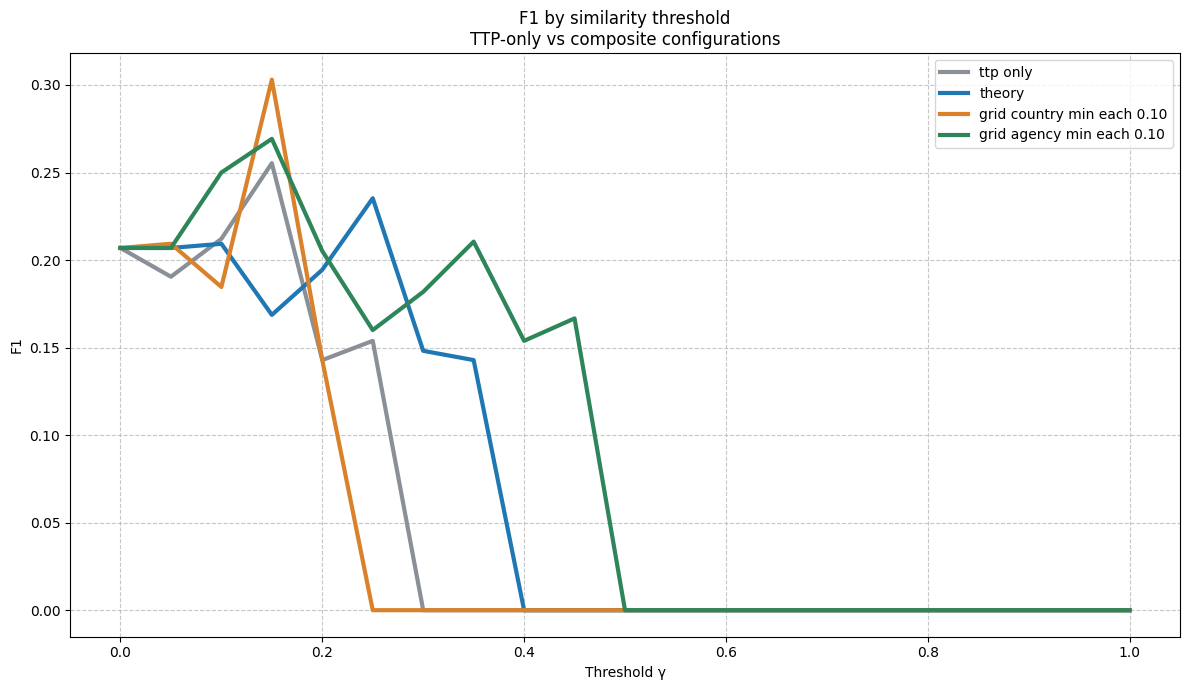

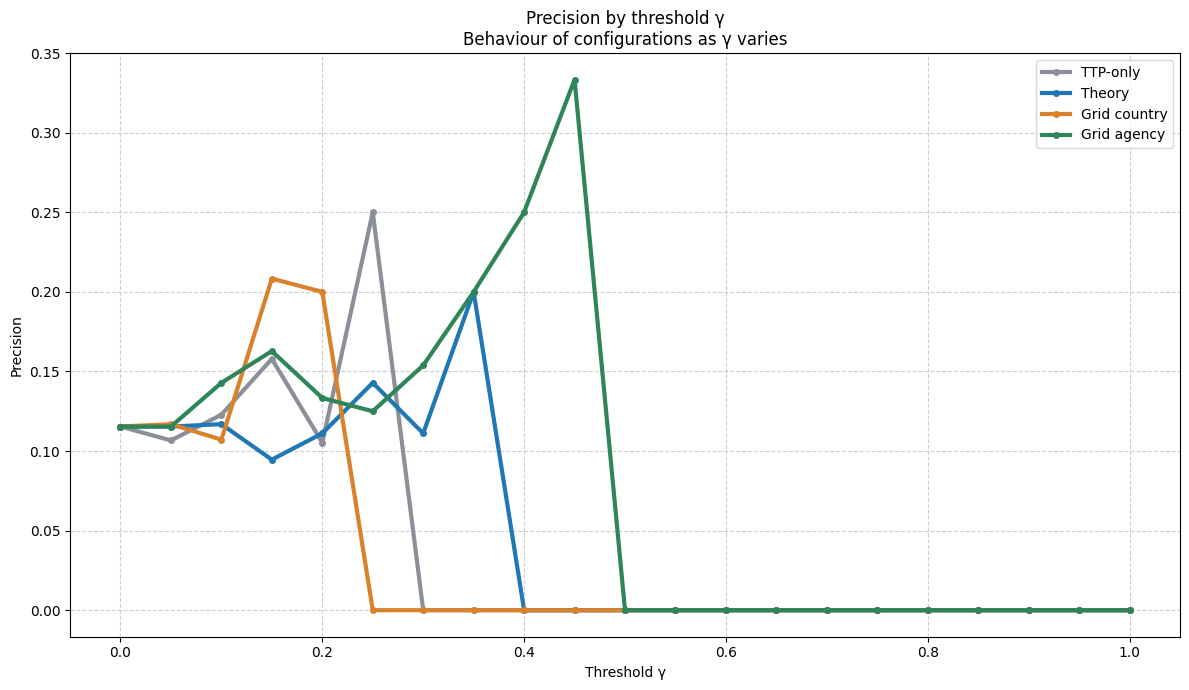

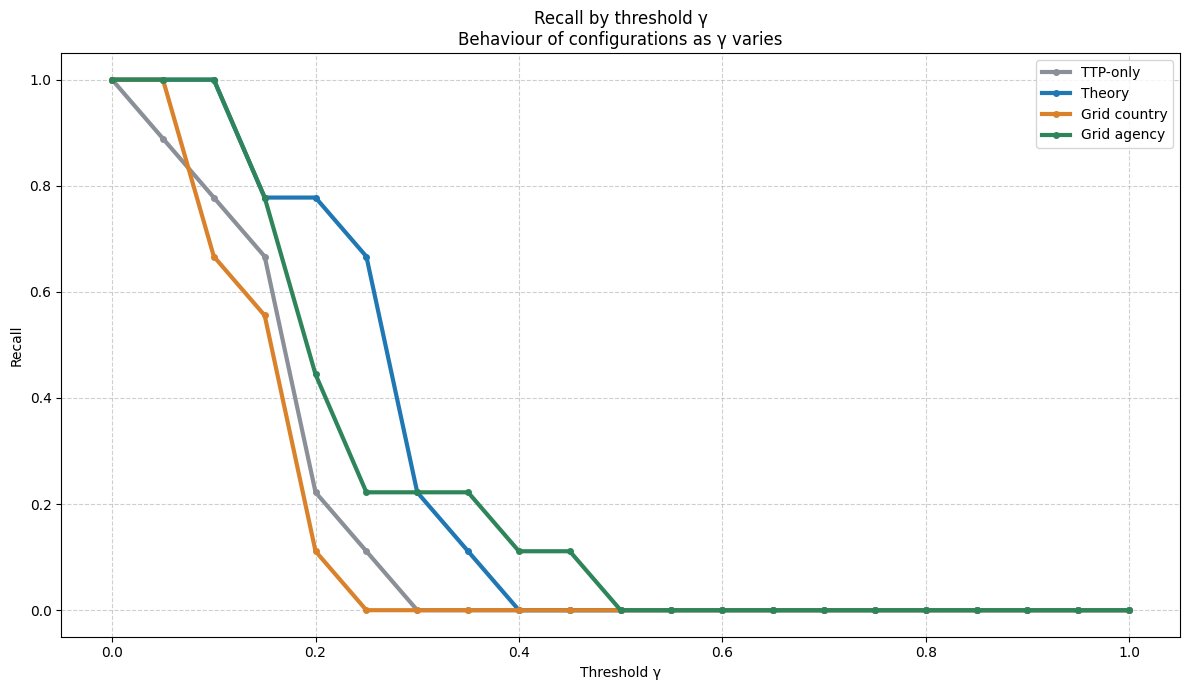

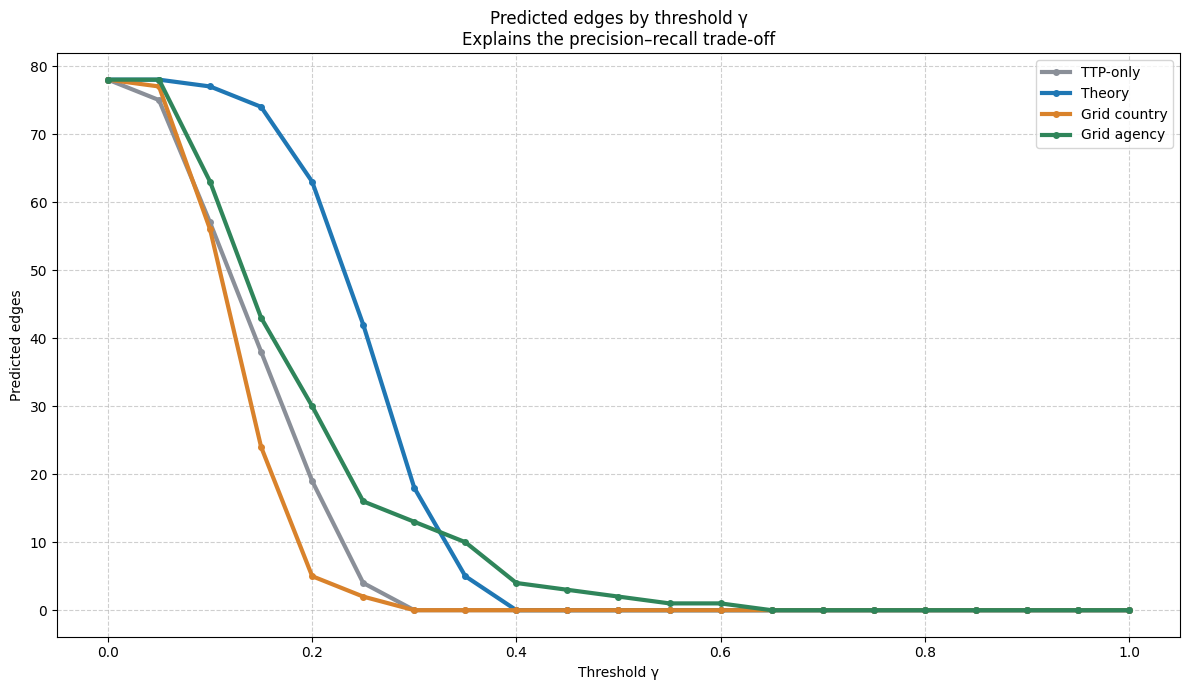

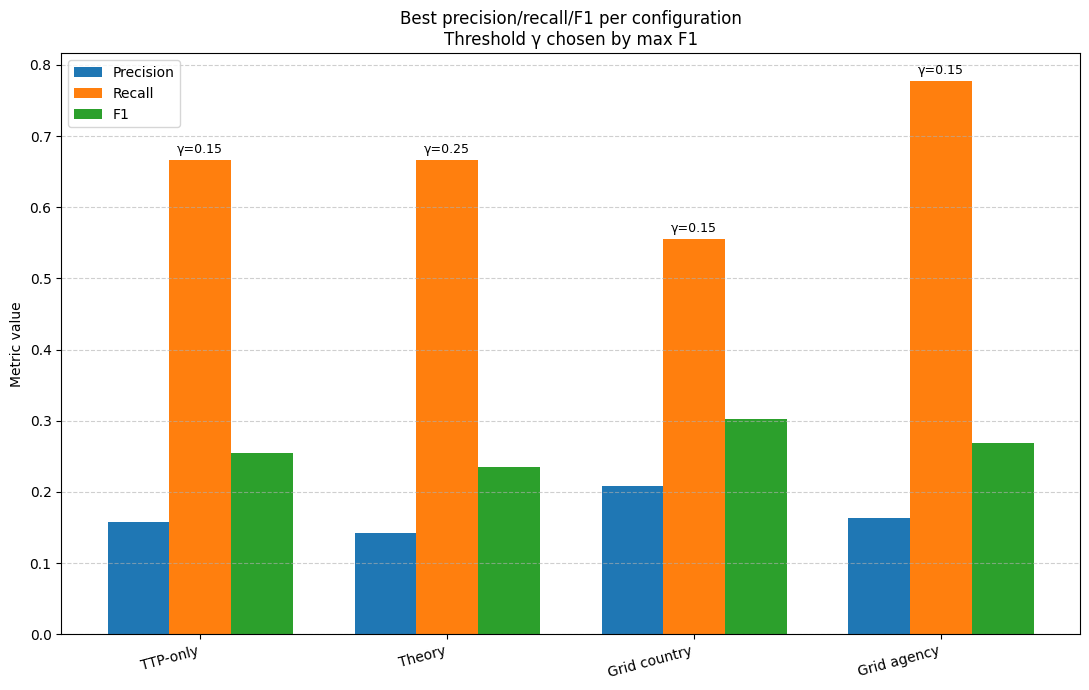

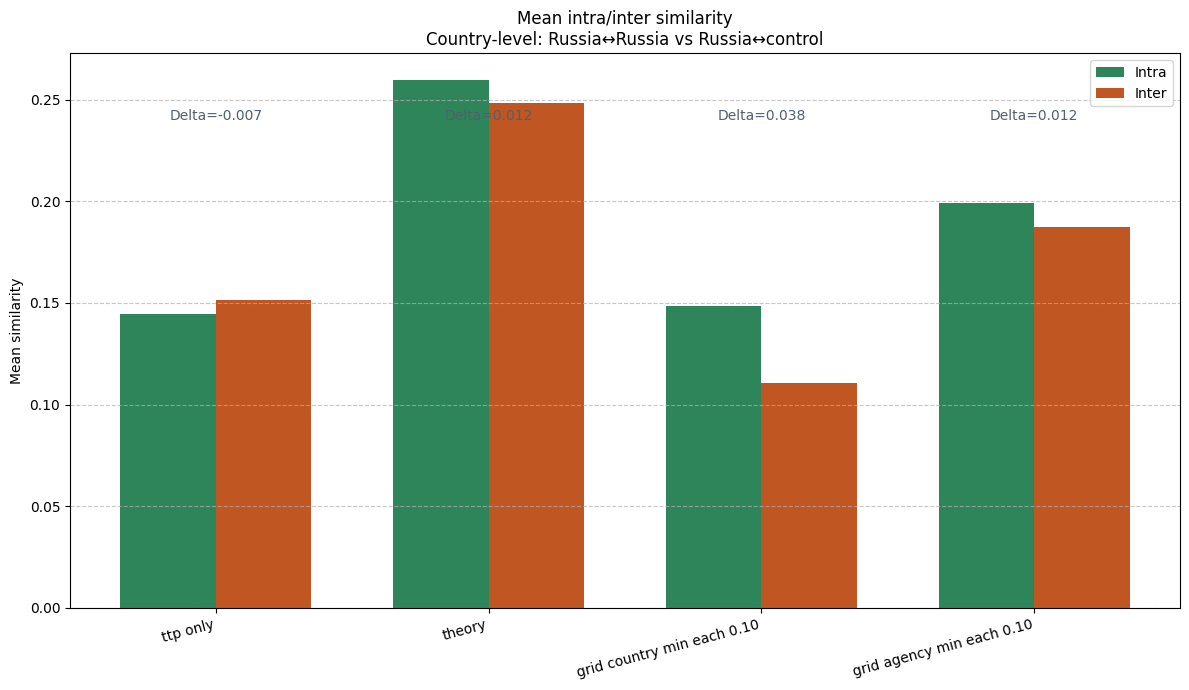

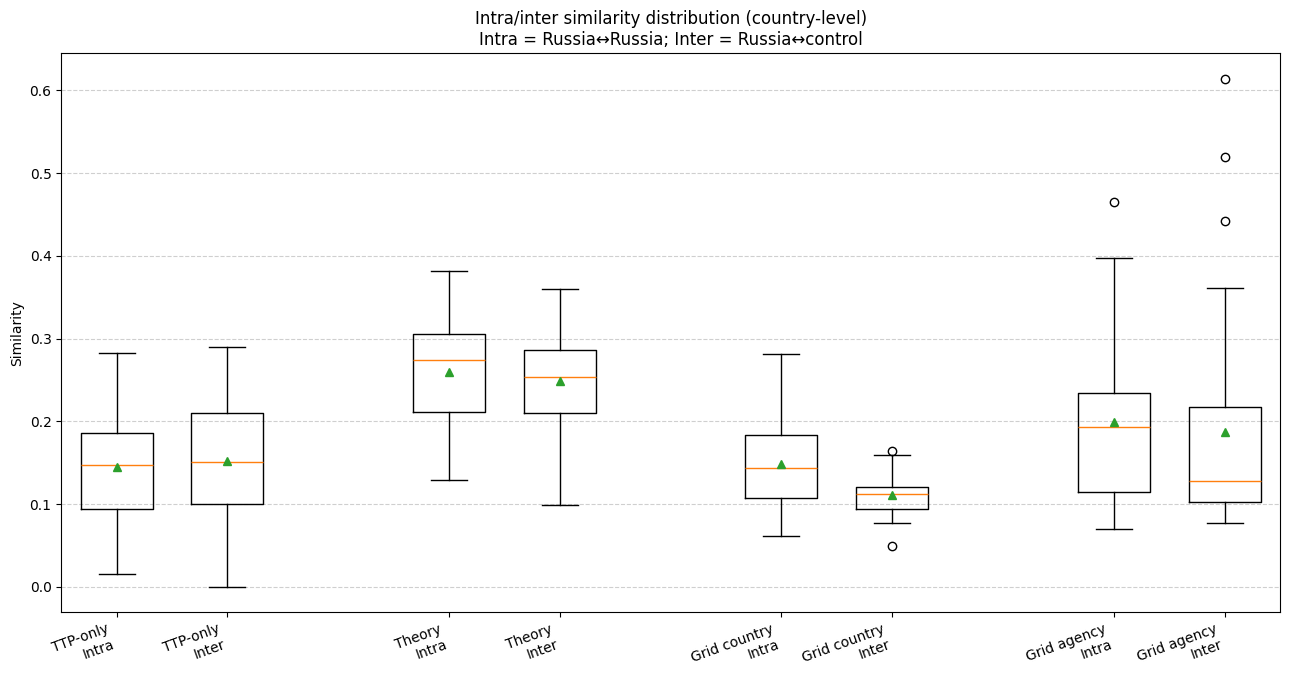

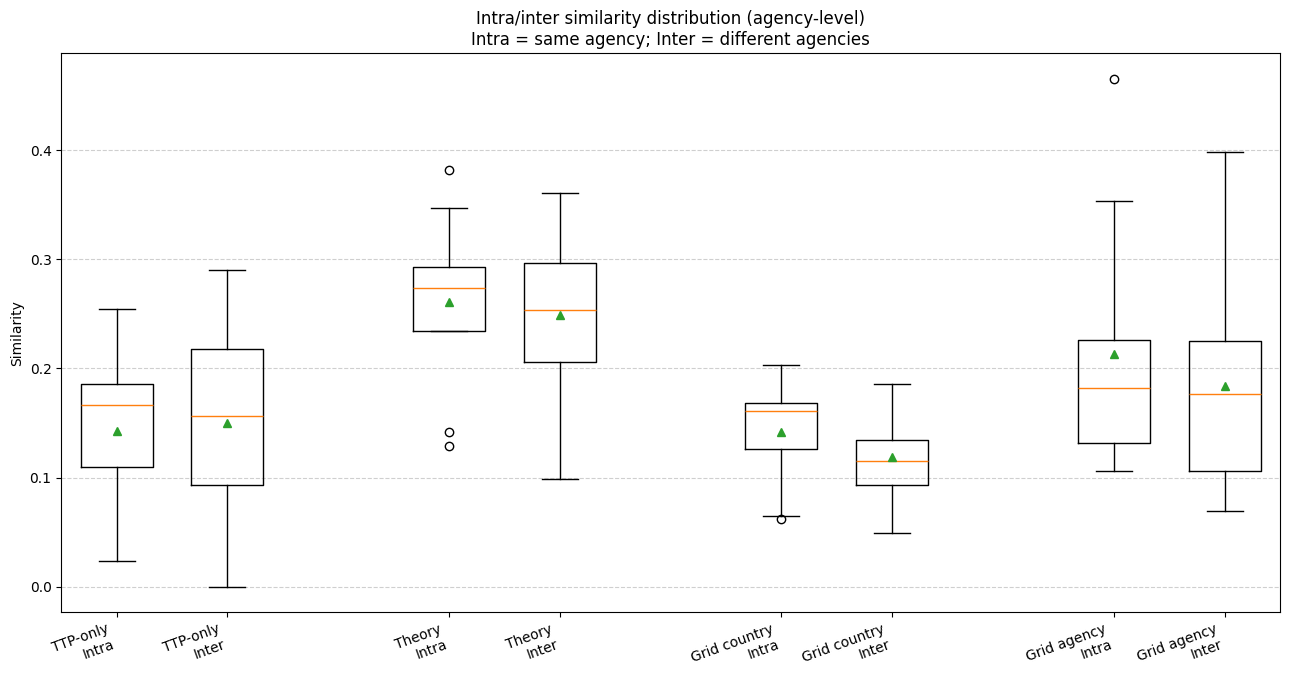

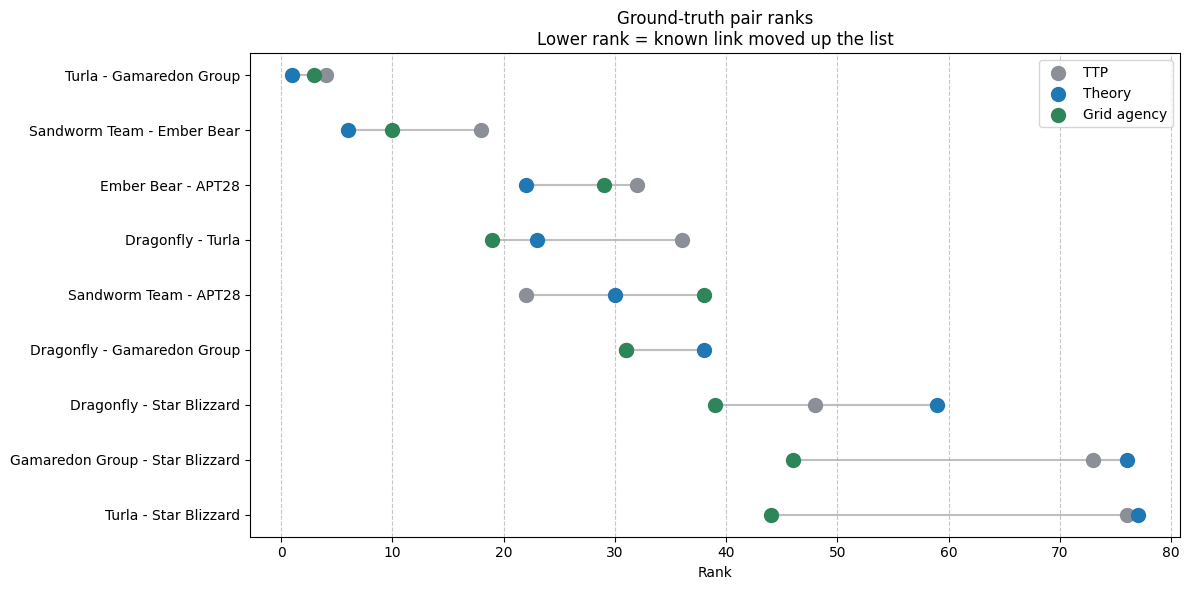

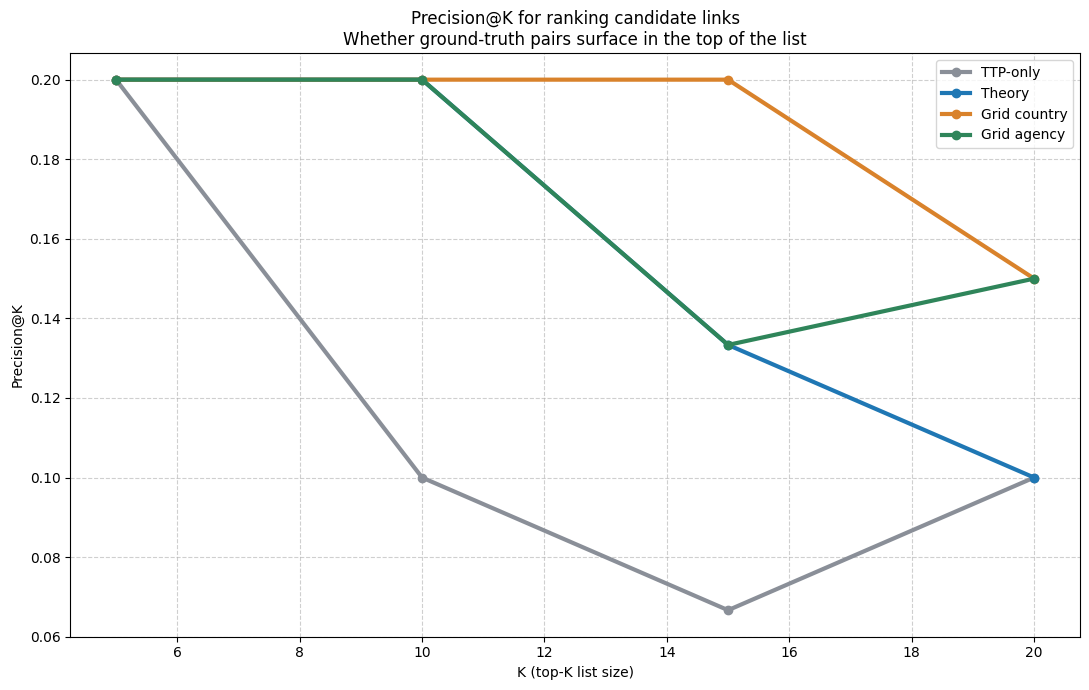

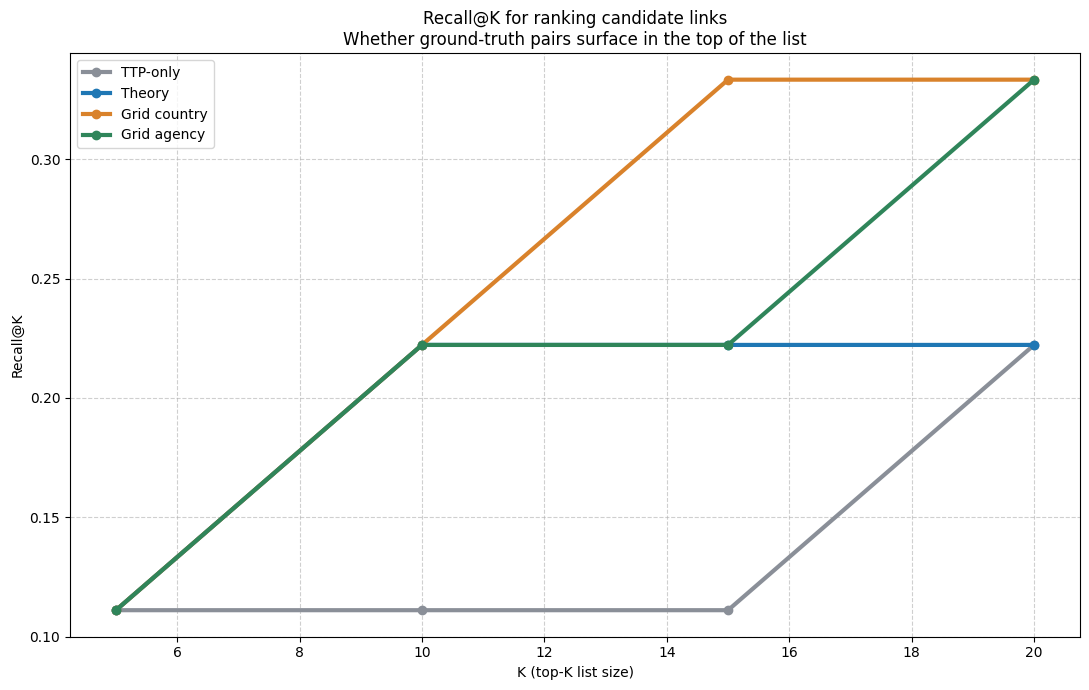

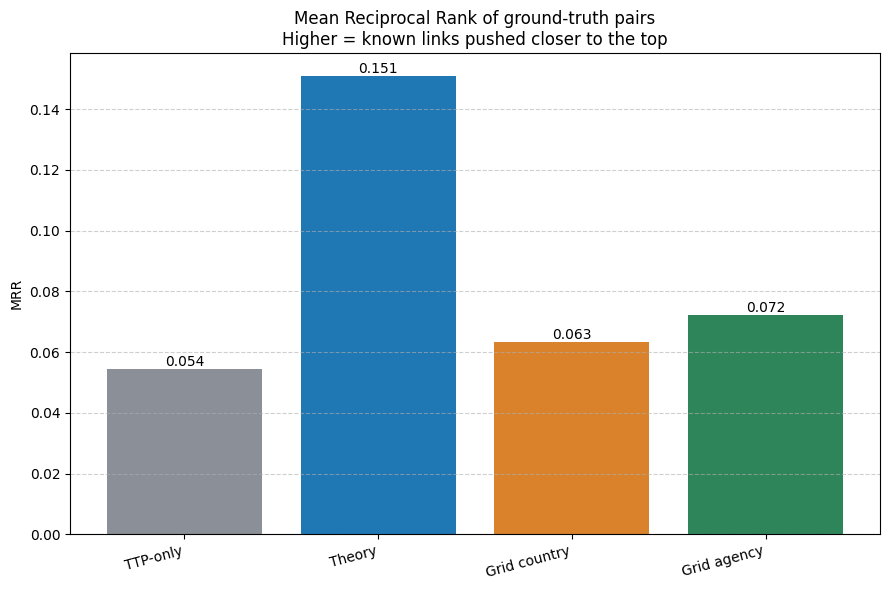

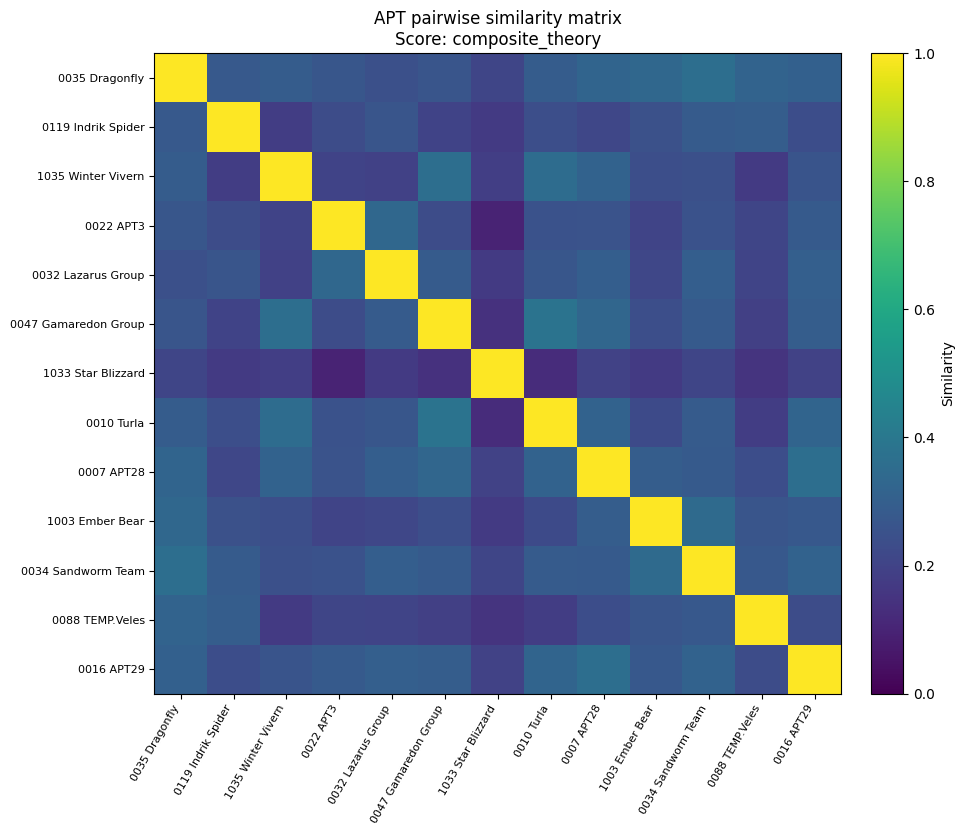

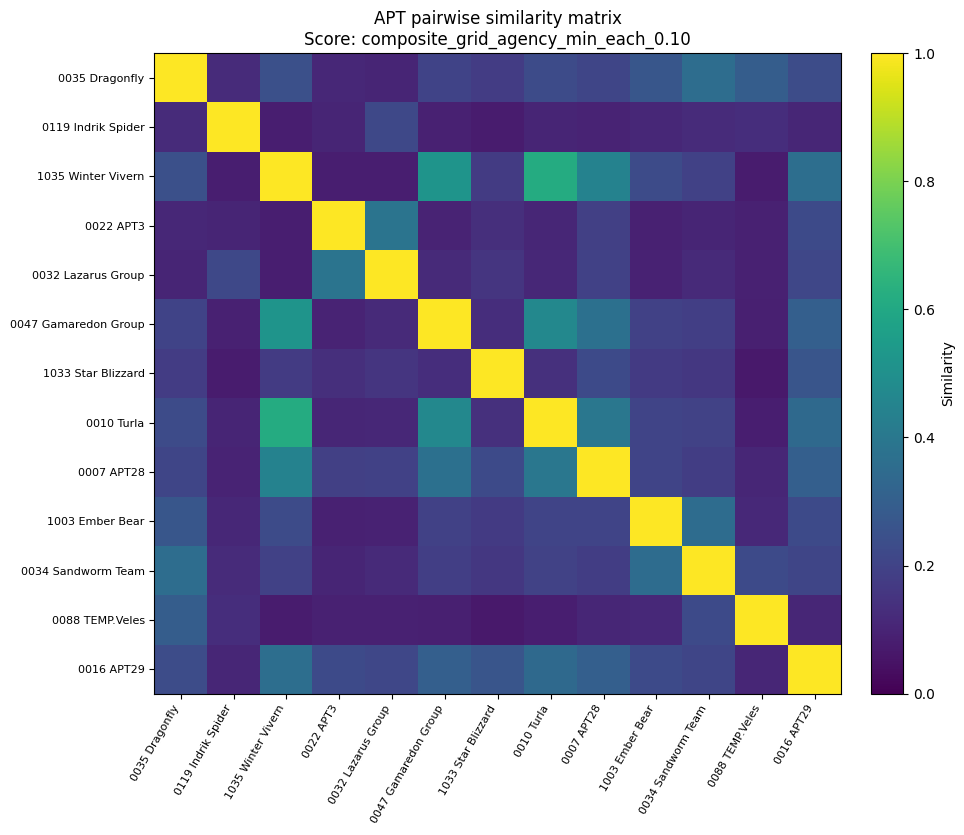

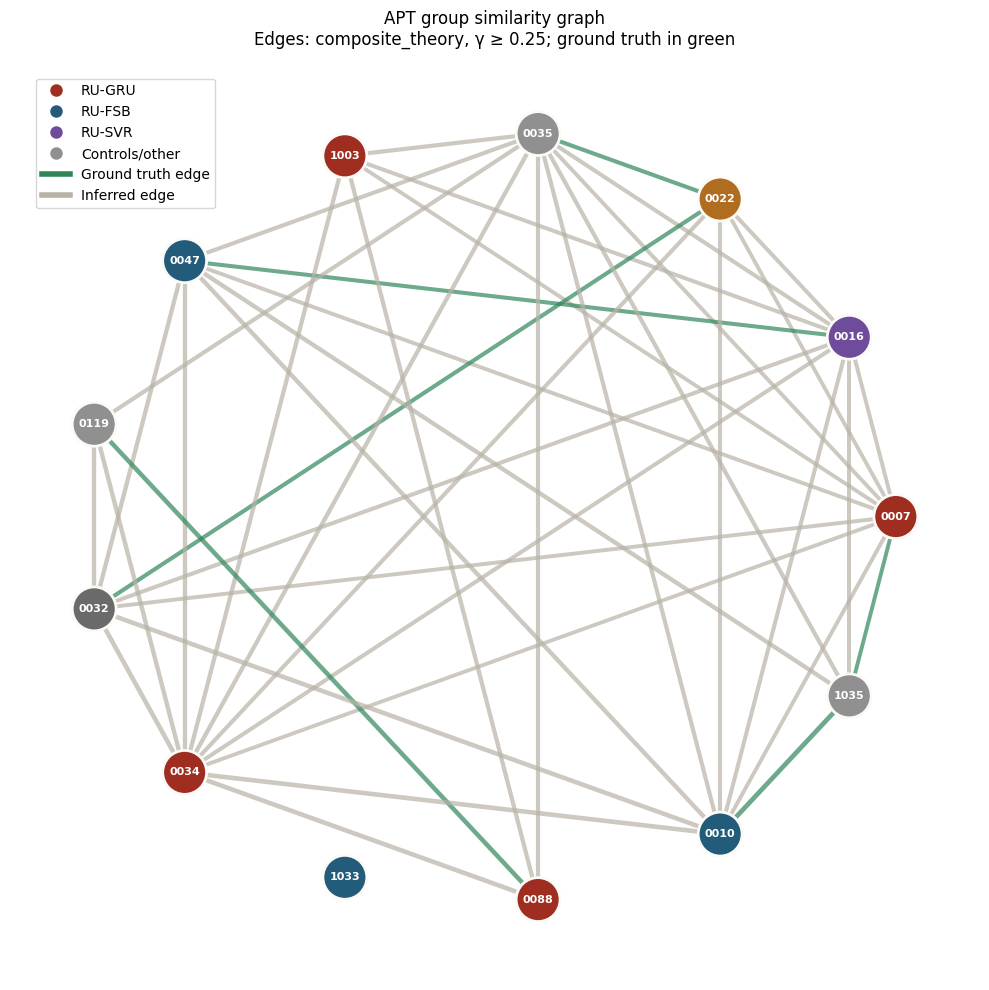

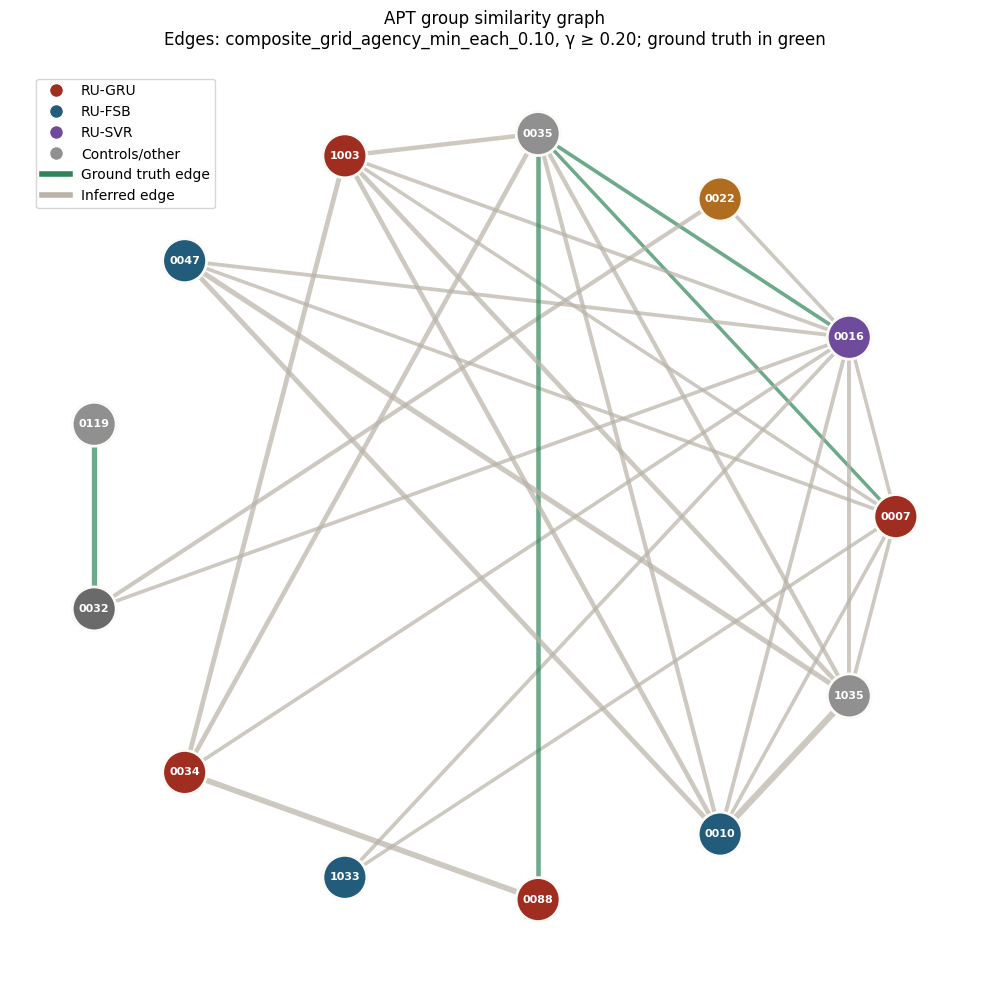

Best country grid: delta=0.052, weights=(0.0, 0.0, 1.0, 0.0)
Best agency grid: delta=0.038, weights=(0.0, 1.0, 0.0, 0.0)
Best constrained country grid: delta=0.038, weights=(0.1, 0.1, 0.7, 0.1)
Best constrained agency grid: delta=0.029, weights=(0.1, 0.7, 0.1, 0.1)


In [21]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
figures_dir = OUTPUT_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

features = load_features(DATA_PATH, keep_ambiguous_agencies=KEEP_AMBIGUOUS_AGENCIES)
rows = build_pair_rows(features)

summaries = [
    summarize_weight_set(rows, label, weights)
    for label, weights in DEFAULT_WEIGHTS.items()
]

best_country = grid_search(rows, "country", GRID_STEP)
best_agency = grid_search(rows, "agency", GRID_STEP)
best_country_constrained = grid_search(rows, "country", GRID_STEP, min_each_weight=0.10)
best_agency_constrained = grid_search(rows, "agency", GRID_STEP, min_each_weight=0.10)

add_composite_column(rows, "composite_grid_country_min_each_0.10", best_country_constrained["weights"])
add_composite_column(rows, "composite_grid_agency_min_each_0.10", best_agency_constrained["weights"])

ground_truth = load_ground_truth(GROUND_TRUTH_PATH)
annotate_ground_truth(rows, ground_truth)

pair_fields = [
    "left_id", "left_name", "left_country", "left_agency",
    "right_id", "right_name", "right_country", "right_agency",
    "ground_truth_link", "ground_truth_confidence", "ground_truth_relation_type",
    "jaccard_ttp", "cosine_ttp", "overlap_ttp",
    "sector_jaccard", "software_jaccard", "tactical_cosine",
    "composite_ttp_only", "composite_equal", "composite_theory", "composite_ttp_heavy",
    "composite_grid_country_min_each_0.10", "composite_grid_agency_min_each_0.10",
]
write_csv(OUTPUT_DIR / "pairwise_similarity.csv", rows, pair_fields)

summaries.extend([
    summarize_weight_set(rows, "grid_country", best_country["weights"]),
    summarize_weight_set(rows, "grid_agency", best_agency["weights"]),
    summarize_weight_set(rows, "grid_country_min_each_0.10", best_country_constrained["weights"]),
    summarize_weight_set(rows, "grid_agency_min_each_0.10", best_agency_constrained["weights"]),
])
summary_fields = [
    "label", "weights",
    "country_intra_avg", "country_inter_avg", "country_delta",
    "country_intra_pairs", "country_inter_pairs",
    "agency_intra_avg", "agency_inter_avg", "agency_delta",
    "agency_intra_pairs", "agency_inter_pairs",
]
write_csv(OUTPUT_DIR / "similarity_summary.csv", summaries, summary_fields)

threshold_rows = []
for score_column in VALIDATION_SCORES.values():
    threshold_rows.extend(validation_by_threshold(rows, score_column))
validation_fields = ["score", "threshold", "tp", "fp", "fn", "predicted_edges", "precision", "recall", "f1"]
write_csv(OUTPUT_DIR / "ground_truth_validation_by_threshold.csv", threshold_rows, validation_fields)

validation_summaries = validation_summary(rows)
validation_summary_fields = [
    "label", "score_column", "best_threshold",
    "best_precision", "best_recall", "best_f1",
    "best_tp", "best_fp", "best_fn",
    "top_10_gt_hits", "top_15_gt_hits", "mean_ground_truth_rank",
]
write_csv(OUTPUT_DIR / "ground_truth_validation_summary.csv", validation_summaries, validation_summary_fields)

rank_rows = ground_truth_rank_rows(rows)
rank_fields = [
    "pair", "confidence", "relation_type",
    "ttp_only_score", "theory_score", "grid_country_score", "grid_agency_score",
    "ttp_only_rank", "theory_rank", "grid_country_rank", "grid_agency_rank",
]
write_csv(OUTPUT_DIR / "ground_truth_pair_ranks.csv", rank_rows, rank_fields)

write_markdown_report(OUTPUT_DIR / "similarity_report.md", rows, summaries, best_country, best_agency)
write_thesis_tables(OUTPUT_DIR / "thesis_tables.md", rows, summaries)
write_validation_report(OUTPUT_DIR / "ground_truth_validation_report.md", validation_summaries, rank_rows)

ranking_rows = ranking_metrics_at_k(rows)
ranking_fields = [
    "label", "score_column", "k", "hits_at_k", "precision_at_k", "recall_at_k",
    "total_ground_truth", "mrr", "mean_ground_truth_rank",
]
write_csv(OUTPUT_DIR / "ground_truth_ranking_metrics_at_k.csv", ranking_rows, ranking_fields)
write_ranking_metrics_report(OUTPUT_DIR / "ground_truth_ranking_metrics_report.md", ranking_rows)

theory_best = next(row for row in validation_summaries if row["label"] == "theory")
grid_agency_best = next(row for row in validation_summaries if row["label"] == "grid_agency_min_each_0.10")

plot_f1_by_threshold(figures_dir / "f1_by_threshold.png", threshold_rows)
plot_metric_by_threshold(figures_dir / "precision_by_threshold.png", threshold_rows, "precision")
plot_metric_by_threshold(figures_dir / "recall_by_threshold.png", threshold_rows, "recall")
plot_predicted_edges_by_threshold(figures_dir / "predicted_edges_by_threshold.png", threshold_rows)
plot_best_threshold_metrics(figures_dir / "best_threshold_precision_recall_f1.png", validation_summaries)
plot_intra_inter(figures_dir / "intra_inter_country.png", summaries)
plot_intra_inter_boxplot(figures_dir / "intra_inter_country_boxplot.png", rows, "country")
plot_intra_inter_boxplot(figures_dir / "intra_inter_agency_boxplot.png", rows, "agency")
plot_ground_truth_ranks(figures_dir / "ground_truth_ranks.png", rank_rows)
plot_at_k_metric(figures_dir / "precision_at_k.png", ranking_rows, "precision_at_k")
plot_at_k_metric(figures_dir / "recall_at_k.png", ranking_rows, "recall_at_k")
plot_mrr_by_config(figures_dir / "mrr_by_config.png", ranking_rows)
plot_similarity_heatmap(figures_dir / "similarity_heatmap_theory.png", rows, features, "composite_theory")
plot_similarity_heatmap(figures_dir / "similarity_heatmap_grid_agency.png", rows, features, "composite_grid_agency_min_each_0.10")
plot_network(
    figures_dir / "apt_network_theory.png",
    rows, features, "composite_theory",
    max(0.20, theory_best["best_threshold"]),
)
plot_network(
    figures_dir / "apt_network_grid_agency.png",
    rows, features, "composite_grid_agency_min_each_0.10",
    max(0.20, grid_agency_best["best_threshold"]),
)

print(f"Best country grid: delta={best_country['delta']:.3f}, weights={best_country['weights']}")
print(f"Best agency grid: delta={best_agency['delta']:.3f}, weights={best_agency['weights']}")
print(f"Best constrained country grid: delta={best_country_constrained['delta']:.3f}, weights={best_country_constrained['weights']}")
print(f"Best constrained agency grid: delta={best_agency_constrained['delta']:.3f}, weights={best_agency_constrained['weights']}")

In [22]:
import pandas as pd

df_pairs = pd.read_csv(OUTPUT_DIR / "pairwise_similarity.csv")
print("Top-10 pairs by composite_theory:")
display(
    df_pairs.nlargest(10, "composite_theory")[[
        "left_name", "right_name", "composite_theory",
        "jaccard_ttp", "sector_jaccard", "software_jaccard", "tactical_cosine",
        "ground_truth_link",
    ]]
)

Top-10 pairs by composite_theory:


,left_name,right_name,composite_theory,jaccard_ttp,sector_jaccard,software_jaccard,tactical_cosine,ground_truth_link
45,Turla,Gamaredon Group,0.381836,0.254545,0.500000,0.028571,0.871519,1
13,Dragonfly,Sandworm Team,0.361984,0.220472,0.333333,0.117647,0.917993,0
57,APT28,APT29,0.360570,0.282353,0.250000,0.054054,0.934088,0
69,Gamaredon Group,Winter Vivern,0.360297,0.212500,0.600000,0.000000,0.776487,0
47,Turla,Winter Vivern,0.354560,0.130952,0.750000,0.000000,0.760896,0
34,Sandworm Team,Ember Bear,0.347158,0.204918,0.333333,0.083333,0.909290,1
15,Dragonfly,Ember Bear,0.332848,0.195402,0.200000,0.166667,0.906768,0
29,Lazarus Group,APT3,0.332136,0.207407,0.400000,0.000000,0.845865,0
58,APT28,Gamaredon Group,0.329381,0.215827,0.375000,0.000000,0.840248,0
16,Dragonfly,APT28,0.323540,0.260163,0.125000,0.083333,0.889040,0


In [23]:
df_summary = pd.read_csv(OUTPUT_DIR / "similarity_summary.csv")
display(df_summary[[
    "label", "country_intra_avg", "country_inter_avg", "country_delta",
    "agency_intra_avg", "agency_inter_avg", "agency_delta",
]])

,label,country_intra_avg,country_inter_avg,country_delta,agency_intra_avg,agency_inter_avg,agency_delta
0,ttp_only,0.144582,0.151687,-0.007105,0.142407,0.149729,-0.007322
1,equal,0.288683,0.272453,0.016230,0.290134,0.273207,0.016926
2,theory,0.259863,0.248300,0.011563,0.260588,0.248512,0.012076
3,ttp_heavy,0.231042,0.224146,0.006896,0.231043,0.223816,0.007227
4,grid_country,0.054876,0.002990,0.051886,0.043222,0.016677,0.026545
5,grid_agency,0.139118,0.130529,0.008589,0.162346,0.124592,0.037754
6,grid_country_min_each_0.10,0.148399,0.110775,0.037624,0.141986,0.119289,0.022697
7,grid_agency_min_each_0.10,0.198944,0.187299,0.011645,0.213461,0.184038,0.029423


In [24]:
df_val = pd.read_csv(OUTPUT_DIR / "ground_truth_validation_summary.csv")
display(df_val[[
    "label", "best_threshold", "best_precision", "best_recall", "best_f1",
    "top_10_gt_hits", "mean_ground_truth_rank",
]])

,label,best_threshold,best_precision,best_recall,best_f1,top_10_gt_hits,mean_ground_truth_rank
0,ttp_only,0.15,0.157895,0.666667,0.255319,1,37.777778
1,equal,0.30,0.156250,0.555556,0.243902,2,36.000000
2,theory,0.25,0.142857,0.666667,0.235294,2,36.888889
3,ttp_heavy,0.25,0.151515,0.555556,0.238095,2,37.111111
4,grid_country_min_each_0.10,0.15,0.208333,0.555556,0.303030,2,34.666667
5,grid_agency_min_each_0.10,0.15,0.162791,0.777778,0.269231,2,28.777778


In [25]:
df_rank_metrics = pd.read_csv(OUTPUT_DIR / "ground_truth_ranking_metrics_at_k.csv")
display(df_rank_metrics[[
    "label", "k", "hits_at_k", "precision_at_k", "recall_at_k", "mrr", "mean_ground_truth_rank",
]])


,label,k,hits_at_k,precision_at_k,recall_at_k,mrr,mean_ground_truth_rank
0,ttp_only,5,1,0.200000,0.111111,0.054443,37.777778
1,ttp_only,10,1,0.100000,0.111111,0.054443,37.777778
2,ttp_only,15,1,0.066667,0.111111,0.054443,37.777778
3,ttp_only,20,2,0.100000,0.222222,0.054443,37.777778
4,theory,5,1,0.200000,0.111111,0.150927,36.888889
5,theory,10,2,0.200000,0.222222,0.150927,36.888889
6,theory,15,2,0.133333,0.222222,0.150927,36.888889
7,theory,20,2,0.100000,0.222222,0.150927,36.888889
8,grid_country_min_each_0.10,5,1,0.200000,0.111111,0.063420,34.666667
9,grid_country_min_each_0.10,10,2,0.200000,0.222222,0.063420,34.666667
